In [102]:
import matplotlib.pyplot as plt
import cv2
%matplotlib inline

In [103]:
cat4 = cv2.imread("../DATA/CATS_DOGS/train/CAT/4.jpg")
cat4 = cv2.cvtColor(cat4, cv2.COLOR_BGR2RGB)

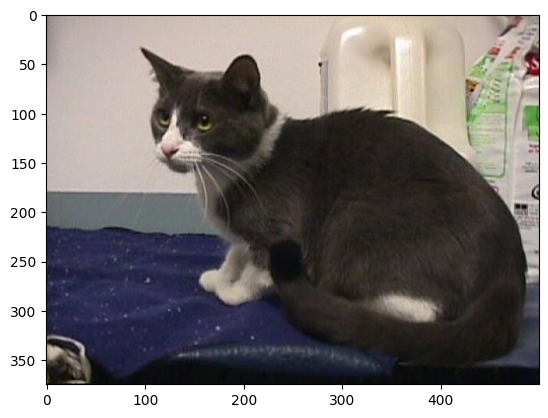

In [104]:
plt.imshow(cat4)

In [105]:
cat4.shape

(375, 500, 3)

In [106]:
dog = cv2.imread("../DATA/CATS_DOGS/train/DOG/2.jpg")
dog = cv2.cvtColor(dog, cv2.COLOR_BGR2RGB)

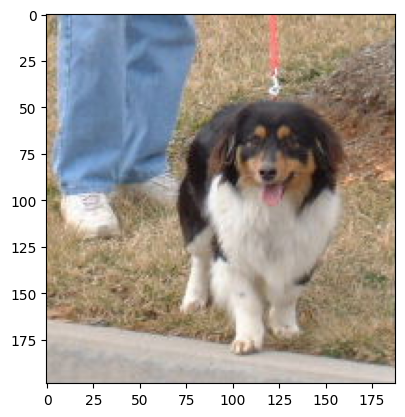

In [107]:
plt.imshow(dog)

In [108]:
dog.shape

(199, 188, 3)

In [109]:
from keras.src.legacy.preprocessing.image import ImageDataGenerator

In [110]:
image_gen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.1,
    height_shift_range=0.1,
    rescale=1/255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

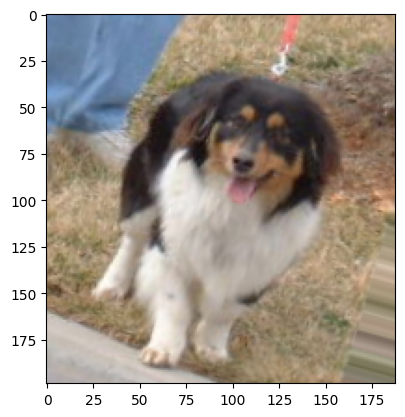

In [111]:
plt.imshow(image_gen.random_transform(dog))

In [112]:
image_gen.flow_from_directory("../DATA/CATS_DOGS/train")

Found 18743 images belonging to 2 classes.


In [113]:
from keras.models import Sequential
from keras.layers import Activation,Dropout,Flatten,Conv2D,MaxPooling2D,Dense

In [114]:
input_shape = (150, 150, 3)

In [115]:
model = Sequential()
model.add(Conv2D(filters=32, kernel_size=(3,3), input_shape=input_shape, activation="relu"))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(filters=64, kernel_size=(3,3), input_shape=input_shape, activation="relu"))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(filters=64, kernel_size=(3,3), input_shape=input_shape, activation="relu"))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())
model.add(Dense(128))
model.add(Activation("relu"))

model.add(Dropout(0.5))

model.add(Dense(1))

model.add(Activation("sigmoid"))

model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)


In [116]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 34, 34, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 17, 17, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 18496)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │     2,367,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           129 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,424,065 (9.25 MB)

 Trainable params: 2,424,065 (9.25 MB)

 Non-trainable params: 0 (0.00 B)

In [117]:
batch_size = 16
train_image_gen = image_gen.flow_from_directory(
    "../DATA/CATS_DOGS/train", 
    target_size=input_shape[:2],
    batch_size=batch_size,
    class_mode="binary"
)
train_image_gen


Found 18743 images belonging to 2 classes.


In [118]:
test_image_gen = image_gen.flow_from_directory(
    "../DATA/CATS_DOGS/test", 
    target_size=input_shape[:2],
    batch_size=batch_size,
    class_mode="binary"
)
test_image_gen

Found 6251 images belonging to 2 classes.


In [119]:
train_image_gen.class_indices

{'CAT': 0, 'DOG': 1}

In [123]:
results = model.fit(
    train_image_gen, 
    epochs=1,
    steps_per_epoch=150,
    validation_data=test_image_gen
)
results

150/150 ━━━━━━━━━━━━━━━━━━━━ 29s 195ms/step - accuracy: 0.4992 - loss: 0.6938 - val_accuracy: 0.4999 - val_loss: 0.7047


In [125]:
import warnings
warnings.filterwarnings("ignore")

In [127]:
results.history["accuracy"]

[0.5045833587646484]

In [129]:
from keras.models import load_model

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'cat_dog_100epochs.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)